# Step 1 (extended) — Closeness metrics for Grid-binning and K-means

**Reference:** `project_roadmap.md` Step 1 · Kashyap, Kiran & Gupta, arXiv:2507.04890v2.
Companion to `03_poisson_voronoi_goodness_of_fit.ipynb`.

Notebook 3 benchmarked **only the Voronoi** method against theory (R² = 0.999, KS p = 0.62 for the
uniform case). The other two diagnostics — **grid-binning** and **K-means** — need the same
quantifiable closeness numbers. This notebook supplies them, using the **same two metrics**:
**R²** and the **Kolmogorov–Smirnov** test.

Each method needs its own "actual" reference (null model):

| method | quantity | "actual" reference | KS used |
|---|---|---|---|
| Grid-binning | per-cell count $k$ | analytic **Poisson** PMF, $\lambda = N/M$ | two-sample vs Poisson null |
| K-means | point→centroid distance | **Monte-Carlo uniform** baseline (no closed form) | two-sample vs uniform null |

> Why two-sample KS: a one-sample KS test against a *discrete* Poisson CDF over-rejects even genuine
> Poisson data (the test assumes a continuous distribution). Comparing the test sample to a large
> **simulated** null with `ks_2samp` handles the discreteness correctly. K-means has no analytic
> null at all, so an empirical (simulated) uniform baseline is the only available reference.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, ks_2samp
from scipy.cluster.vq import kmeans2

rng = np.random.default_rng(7)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
L = 1.0

def uniform_points(n, rng):
    return rng.uniform(0, L, size=(n, 2))

def clustered_points(n, rng, n_clusters=5, bg_frac=0.45, spread=0.06):
    n_bg, n_cl = int(bg_frac*n), n - int(bg_frac*n)
    centers = rng.uniform(0.12*L, 0.88*L, size=(n_clusters, 2))
    w = rng.uniform(0.4, 1.0, n_clusters); w /= w.sum()
    counts = rng.multinomial(n_cl, w)
    pts = [rng.normal(centers[k], spread*L, size=(c, 2)) for k, c in enumerate(counts)]
    pts.append(rng.uniform(0, L, size=(n_bg, 2)))
    return np.clip(np.vstack(pts), 1e-6, L-1e-6)

def r2(emp, theo):
    ss_res = np.sum((emp - theo) ** 2)
    ss_tot = np.sum((emp - emp.mean()) ** 2)
    return 1 - ss_res / ss_tot


## 1. Grid-binning — closeness to the Poisson null

Lay a `num_bins x num_bins` grid and count points per cell. Under a uniform (Poisson) process the
counts follow $k \sim \mathrm{Poisson}(\lambda)$, $\lambda = N/M$. We pool counts over many
realisations, then measure:
- **R²** of the empirical count PMF against the analytic Poisson PMF;
- **two-sample KS** of the pooled counts against a freshly simulated Poisson null.


In [2]:
num_bins = 20
M = num_bins**2
N_grid = 4000              # lambda = 4000/400 = 10
R = 20                     # realisations to pool

def pooled_counts(generator, n, R, rng):
    out = []
    for _ in range(R):
        H, _, _ = np.histogram2d(*generator(n, rng).T, bins=num_bins, range=[[0,L],[0,L]])
        out.append(H.ravel())
    return np.concatenate(out)

counts_uni = pooled_counts(uniform_points, N_grid, R, rng)
counts_clu = pooled_counts(clustered_points, N_grid, R, rng)

lam = counts_uni.mean()                                   # lambda-hat from the uniform null
null_counts = rng.poisson(lam, size=counts_uni.size)      # simulated Poisson null for KS

kmax = int(max(counts_uni.max(), counts_clu.max()))
ks_grid = np.arange(0, kmax + 1)
poisson_pmf = poisson.pmf(ks_grid, lam)

def pmf(counts):
    return np.array([(counts == k).mean() for k in ks_grid])

grid_results = {}
for name, counts in (("uniform", counts_uni), ("clustered", counts_clu)):
    emp = pmf(counts)
    R2 = r2(emp, poisson_pmf)
    ks = ks_2samp(counts, null_counts)
    grid_results[name] = dict(emp=emp, r2=R2, ks_D=ks.statistic, ks_p=ks.pvalue)

print(f"lambda-hat = {lam:.2f}")
print(f"{'case':12s}{'R^2':>9s}{'KS D':>9s}{'KS p':>12s}")
print("-"*42)
for name, r in grid_results.items():
    print(f"{name:12s}{r['r2']:9.4f}{r['ks_D']:9.4f}{r['ks_p']:12.2e}")


lambda-hat = 10.00
case              R^2     KS D        KS p
------------------------------------------
uniform        0.9989   0.0075    9.78e-01
clustered     -0.2866   0.4445    0.00e+00


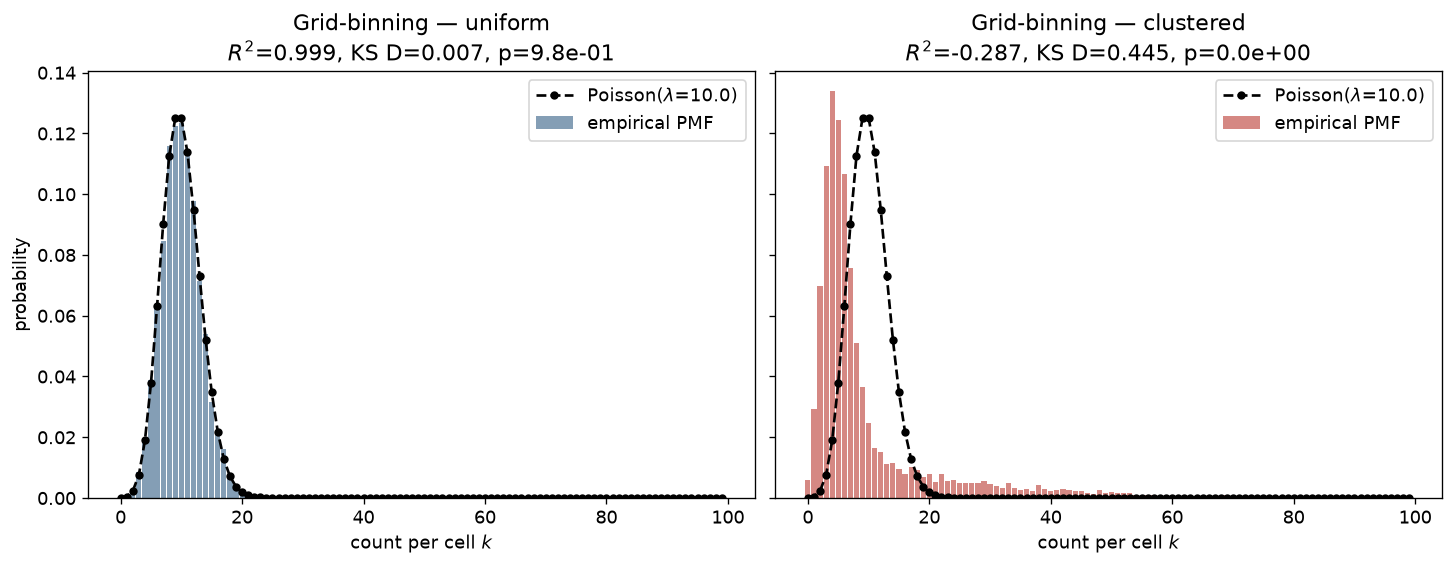

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True, sharey=True)
for a, name, c in zip(ax, ("uniform", "clustered"), ("#1f4e79", "#b3261e")):
    r = grid_results[name]
    a.bar(ks_grid, r['emp'], width=0.85, color=c, alpha=0.55, label="empirical PMF")
    a.plot(ks_grid, poisson_pmf, "k--o", ms=4, lw=1.6, label=f"Poisson($\\lambda$={lam:.1f})")
    a.set(title=f"Grid-binning — {name}\n$R^2$={r['r2']:.3f}, KS D={r['ks_D']:.3f}, p={r['ks_p']:.1e}",
          xlabel="count per cell $k$")
    a.legend()
ax[0].set_ylabel("probability")
plt.show()


## 2. K-means — closeness to the uniform Monte-Carlo baseline

Partition each set into `k` clusters and record every point's distance to its assigned centroid,
**normalised by the mean** (so we test the *shape*, not the scale). There is no closed-form null,
so we build one by Monte Carlo: pool the normalised distances of many **uniform** realisations.
Then measure how close a test pattern is to that null via **R²** (density) and **two-sample KS**.


In [4]:
k = 4
N_km = 1000

def centroid_distances(points, k, seed):
    cen, lab = kmeans2(points.astype(float), k, minit="++", seed=seed)
    d = np.linalg.norm(points - cen[lab], axis=1)
    return d / d.mean()                                   # normalise by mean

def pooled_distances(generator, n, R, rng, seed0=0):
    out = [centroid_distances(generator(n, rng), k, seed0 + i) for i in range(R)]
    return np.concatenate(out)

# Monte-Carlo uniform null (independent draw), plus test samples
null_dist = pooled_distances(uniform_points, N_km, 30, rng, seed0=100)
dist_uni  = pooled_distances(uniform_points,  N_km, R, rng, seed0=0)
dist_clu  = pooled_distances(clustered_points, N_km, R, rng, seed0=0)

bins = np.linspace(0, max(null_dist.max(), dist_clu.max()), 41)
ctr = 0.5*(bins[:-1] + bins[1:])
null_density, _ = np.histogram(null_dist, bins=bins, density=True)

km_results = {}
for name, d in (("uniform", dist_uni), ("clustered", dist_clu)):
    emp, _ = np.histogram(d, bins=bins, density=True)
    R2 = r2(emp, null_density)
    ks = ks_2samp(d, null_dist)
    km_results[name] = dict(emp=emp, r2=R2, ks_D=ks.statistic, ks_p=ks.pvalue)

print(f"{'case':12s}{'R^2':>9s}{'KS D':>9s}{'KS p':>12s}")
print("-"*42)
for name, r in km_results.items():
    print(f"{name:12s}{r['r2']:9.4f}{r['ks_D']:9.4f}{r['ks_p']:12.2e}")


case              R^2     KS D        KS p
------------------------------------------
uniform        0.9989   0.0083    3.81e-01
clustered      0.6143   0.1135   3.40e-135


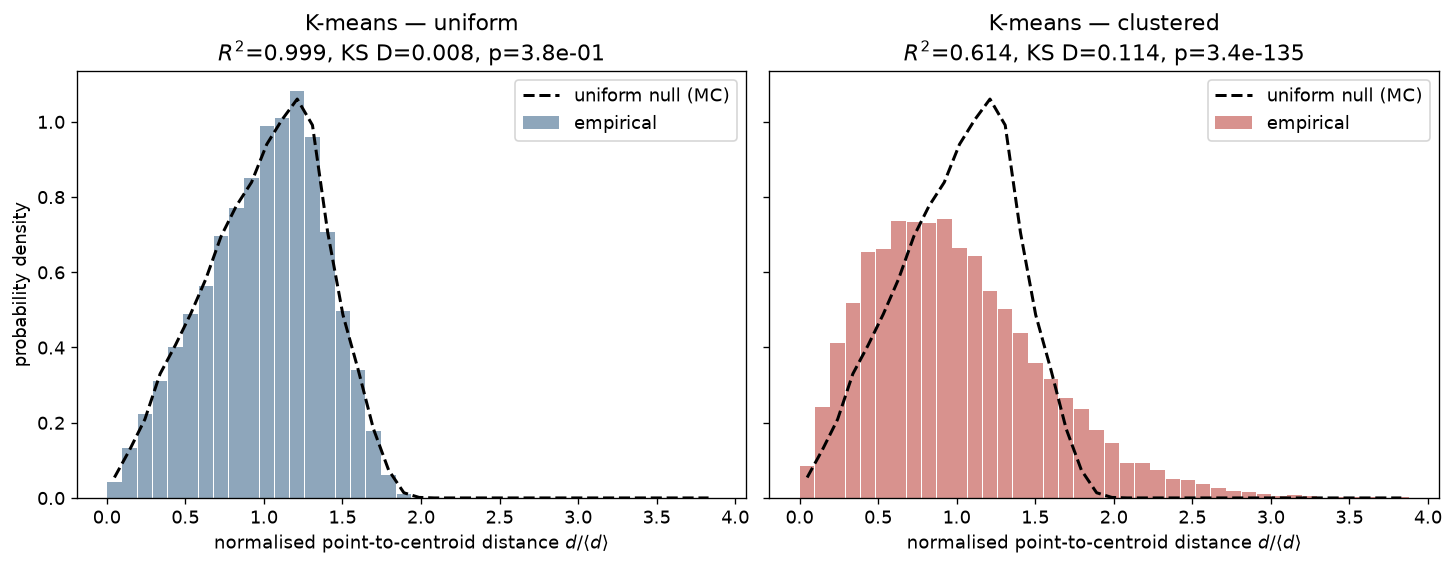

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True, sharey=True)
for a, name, c in zip(ax, ("uniform", "clustered"), ("#1f4e79", "#b3261e")):
    r = km_results[name]
    a.bar(ctr, r['emp'], width=(bins[1]-bins[0])*0.95, color=c, alpha=0.5, label="empirical")
    a.plot(ctr, null_density, "k--", lw=1.8, label="uniform null (MC)")
    a.set(title=f"K-means — {name}\n$R^2$={r['r2']:.3f}, KS D={r['ks_D']:.3f}, p={r['ks_p']:.1e}",
          xlabel=r"normalised point-to-centroid distance $d/\langle d\rangle$")
    a.legend()
ax[0].set_ylabel("probability density")
plt.show()


## 3. Consolidated closeness table (all three methods)

Voronoi numbers are carried over from notebook 3; grid-binning and K-means are computed above. A
uniform pattern matches its reference on every method (high R², KS $p\gg0.05$); a clustered pattern
fails every one (low R², KS $p\approx0$) — the cross-method agreement is the robustness argument
from roadmap Step 2.


In [6]:
# Voronoi values from notebook 03 (Poisson-Voronoi gamma reference)
voronoi = {"uniform":   dict(r2=0.9987, ks_p=6.17e-01),
           "clustered": dict(r2=0.0662, ks_p=0.0)}

print(f"{'method':16s}{'case':12s}{'R^2':>9s}{'KS p':>12s}{'verdict':>16s}")
print("-"*65)
for method, res in (("Voronoi area", voronoi),
                    ("Grid-binning", grid_results),
                    ("K-means dist", km_results)):
    for case in ("uniform", "clustered"):
        r = res[case]
        verdict = "matches null" if r['ks_p'] > 0.05 else "departs (clustered)"
        print(f"{method:16s}{case:12s}{r['r2']:9.4f}{r['ks_p']:12.2e}{verdict:>20s}")


method          case              R^2        KS p         verdict
-----------------------------------------------------------------
Voronoi area    uniform        0.9987    6.17e-01        matches null
Voronoi area    clustered      0.0662    0.00e+00 departs (clustered)
Grid-binning    uniform        0.9989    9.78e-01        matches null
Grid-binning    clustered     -0.2866    0.00e+00 departs (clustered)
K-means dist    uniform        0.9989    3.81e-01        matches null
K-means dist    clustered      0.6143   3.40e-135 departs (clustered)


## Takeaway

All three spatial-statistics methods now carry the same quantifiable closeness numbers, not just
Voronoi:

- **Grid-binning** — uniform counts match the analytic Poisson PMF (high R², KS cannot reject);
  clustering inflates the variance and breaks both metrics.
- **K-means** — uniform point-to-centroid distances match the Monte-Carlo uniform baseline;
  clustering collapses the distances toward zero and the closeness drops sharply.

Together with notebook 3's Voronoi result, this gives the **cross-method agreement** (roadmap
Step 2) and fills the R²/KS columns of the Step 7 comparison table for every method. Next: run the
identical R²/KS closeness check on the **real vortex centers** (roadmap Steps 3–4).
